# Percolation Benchmark Analysis

This notebook is a thin interactive wrapper around `percolation_uart.analysis`.

It keeps the SQLite loading and plotting logic in the analysis module, so the notebook can stay lightweight while you inspect sessions, select a run, and render the standard plots inline.

In [5]:
from __future__ import annotations

import sys
import tempfile
from pathlib import Path

from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'python' / 'percolation_uart' / 'analysis.py').exists():
            return candidate
    raise FileNotFoundError('could not locate repository root')

repo_root = find_repo_root()
python_dir = repo_root / 'python'
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from percolation_uart import analysis

db_path = analysis.DEFAULT_DB
plot_dir = repo_root / 'python' / 'output' / 'notebook_analysis'
plot_dir.mkdir(parents=True, exist_ok=True)
db_path, plot_dir

(PosixPath('/home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/benchmark.sqlite3'),
 PosixPath('/home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/notebook_analysis'))

In [6]:
conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    print(analysis.summarize_db(conn))
    print()
    for index, session in enumerate(sessions, start=1):
        payload = session.payload
        print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
        if 'config_hash' in payload:
            print(f'    config_hash={payload["config_hash"]}')
        if 'args' in payload and isinstance(payload['args'], dict):
            args = payload['args']
            print(f'    runs={args.get("runs")} repeats={args.get("repeats")} points={args.get("points")} steps={args.get("steps")}')
finally:
    conn.close()

sessions=1, summary_rows=21, raw_rows=42, p_range=[0.5500, 0.6500]

 1. session_id=9f85aa91-dae5-4ac6-b479-bfa447cf87ff created_at=2026-05-25T15:29:31.257824+00:00


In [7]:
selected_session_index = 0

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    if not sessions:
        raise RuntimeError(f'no sessions found in {db_path}')
    selected_session = sessions[selected_session_index]
    selected_session_id = selected_session.session_id
    summary_rows = analysis.load_summary_rows(conn, session_id=selected_session_id)
    raw_rows = analysis.load_raw_rows(conn, session_id=selected_session_id)
finally:
    conn.close()

print(f'selected_session_id={selected_session_id}')
print(f'selected_created_at={selected_session.created_at}')
print(f'summary_rows={len(summary_rows)} raw_rows={len(raw_rows)}')

selected_session_id=9f85aa91-dae5-4ac6-b479-bfa447cf87ff
selected_created_at=2026-05-25T15:29:31.257824+00:00
summary_rows=21 raw_rows=42


In [8]:
import matplotlib.pyplot as plt

runs = float(selected_session.payload.get('args', {}).get('runs', raw_rows[0]['runs']))
steps = float(selected_session.payload.get('args', {}).get('steps', raw_rows[0]['steps']))
ideal_core_cycles_per_run = steps * 3.0 + 3.0
wire_cycles_per_run = float(raw_rows[0]['uart_wire_s']) * 100_000_000.0 / runs

p_values = [float(row['p']) for row in summary_rows]
measured_cycles = [float(row['hw_latency_per_run_cycles']) for row in summary_rows]
core_est_cycles = [float(row['hw_core_latency_per_run_cycles_est']) for row in summary_rows]
uart_and_host_cycles = [value - ideal_core_cycles_per_run for value in measured_cycles]
wire_cycles = [wire_cycles_per_run for _ in p_values]
residual_cycles = [value - wire_cycles_per_run for value in uart_and_host_cycles]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(p_values, measured_cycles, 'o-', label='Measured latency per run')
axes[0].plot(p_values, core_est_cycles, 's-', label='Core estimate from benchmark')
axes[0].axhline(ideal_core_cycles_per_run, color='black', linestyle='--', label=f'Ideal core budget ~{ideal_core_cycles_per_run:.0f} cycles/run')
axes[0].set_ylabel('Cycles per run')
axes[0].set_title('Latency decomposition for the selected session')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(p_values, uart_and_host_cycles, 'o-', label='Measured overhead beyond ideal core')
axes[1].plot(p_values, wire_cycles, 's-', label='Theoretical UART wire time per run')
axes[1].plot(p_values, residual_cycles, '^-', label='Overhead after subtracting wire time')
axes[1].set_xlabel('Occupation probability p')
axes[1].set_ylabel('Cycles per run')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'ideal_core_cycles_per_run={ideal_core_cycles_per_run:.3f}')
print(f'wire_cycles_per_run={wire_cycles_per_run:.3f}')
print(f'measured_minus_ideal_core_first_p={uart_and_host_cycles[0]:.3f}')
print(f'measured_minus_ideal_core_minus_wire_first_p={residual_cycles[0]:.3f}')

KeyError: 'uart_wire_s'

dashboard.png


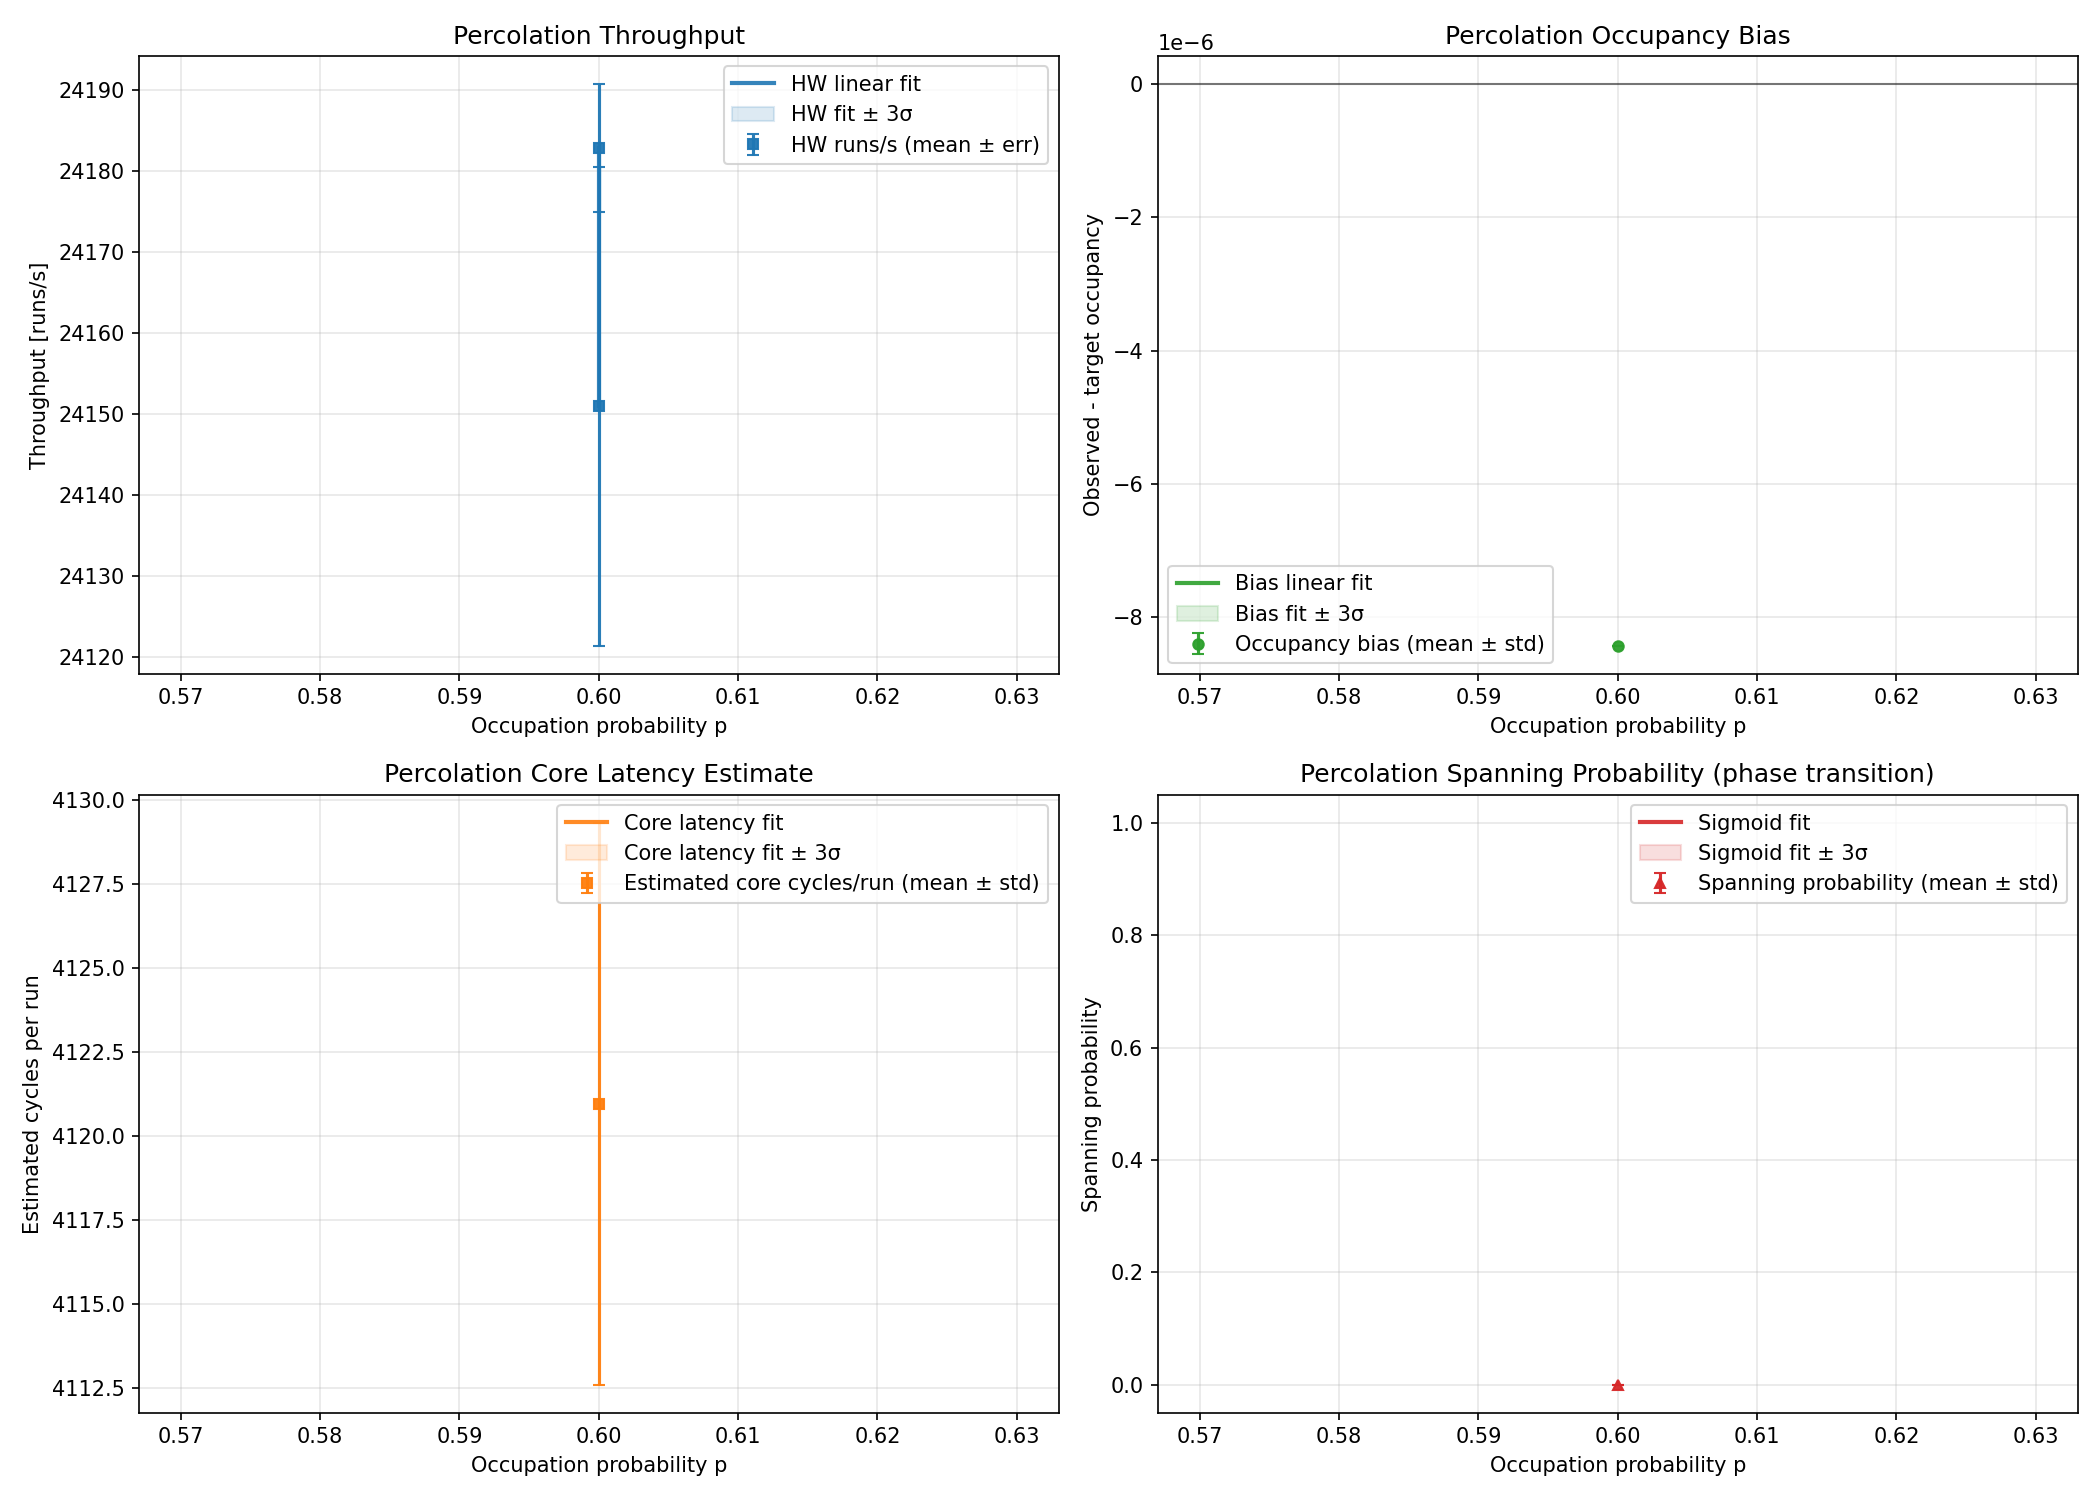

front_density.png


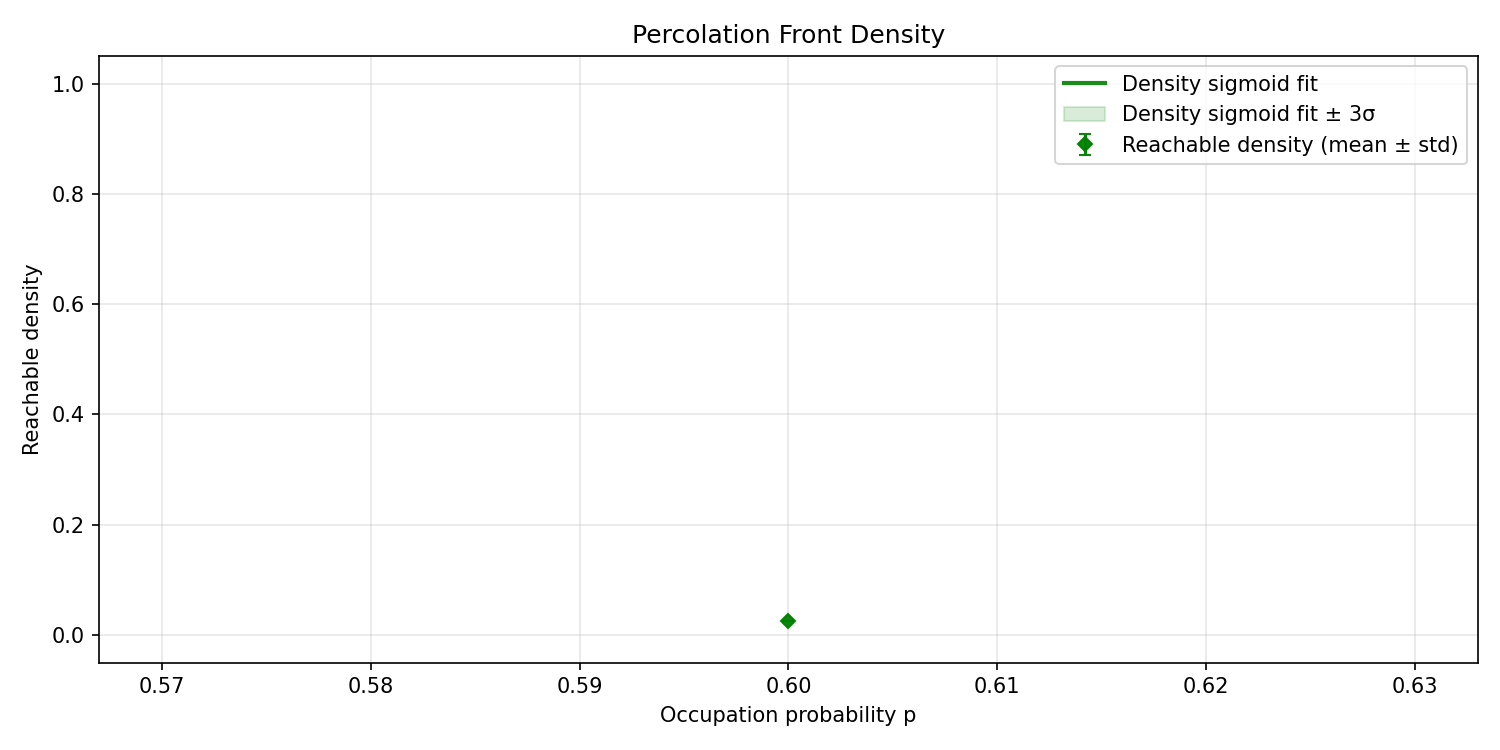

cluster_mass.png


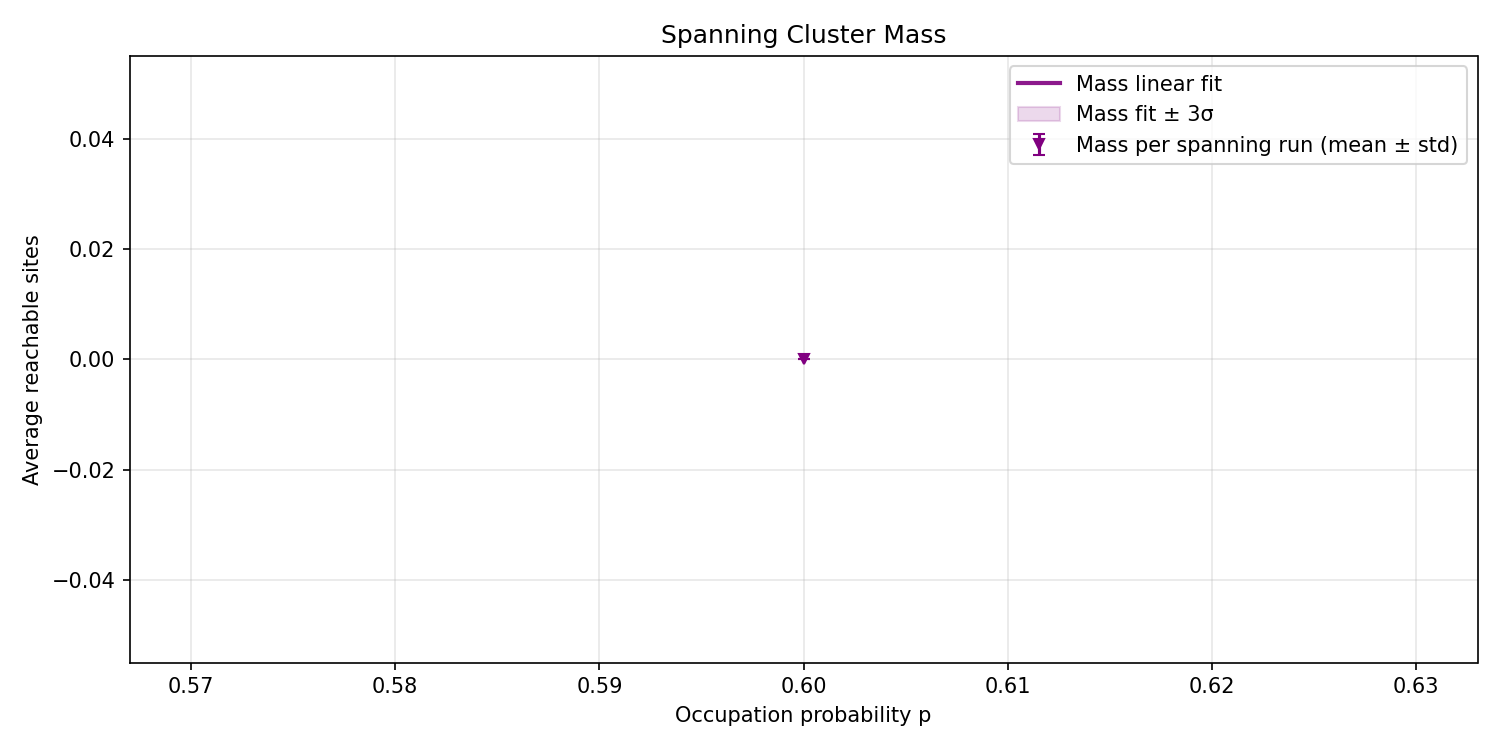

occupancy_bias.png


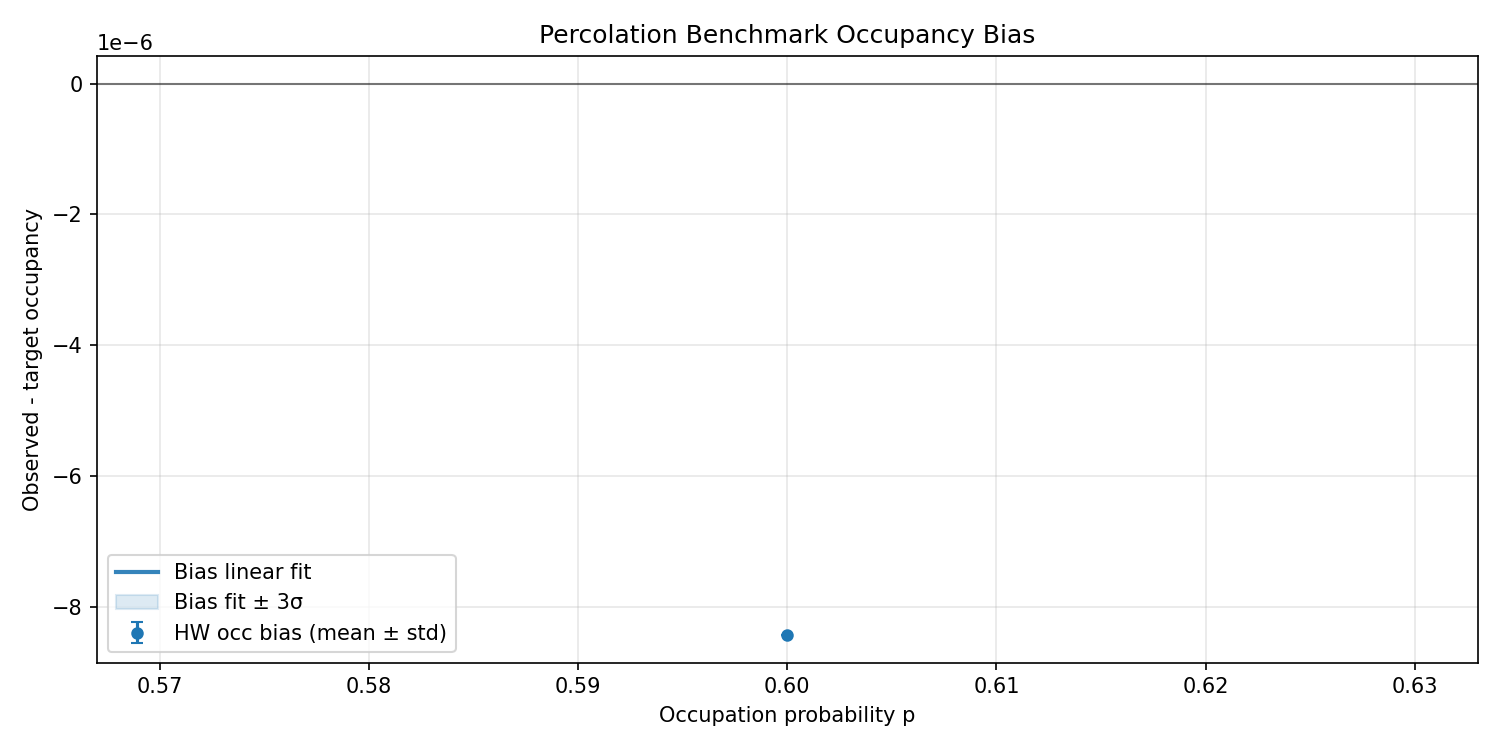

core_latency.png


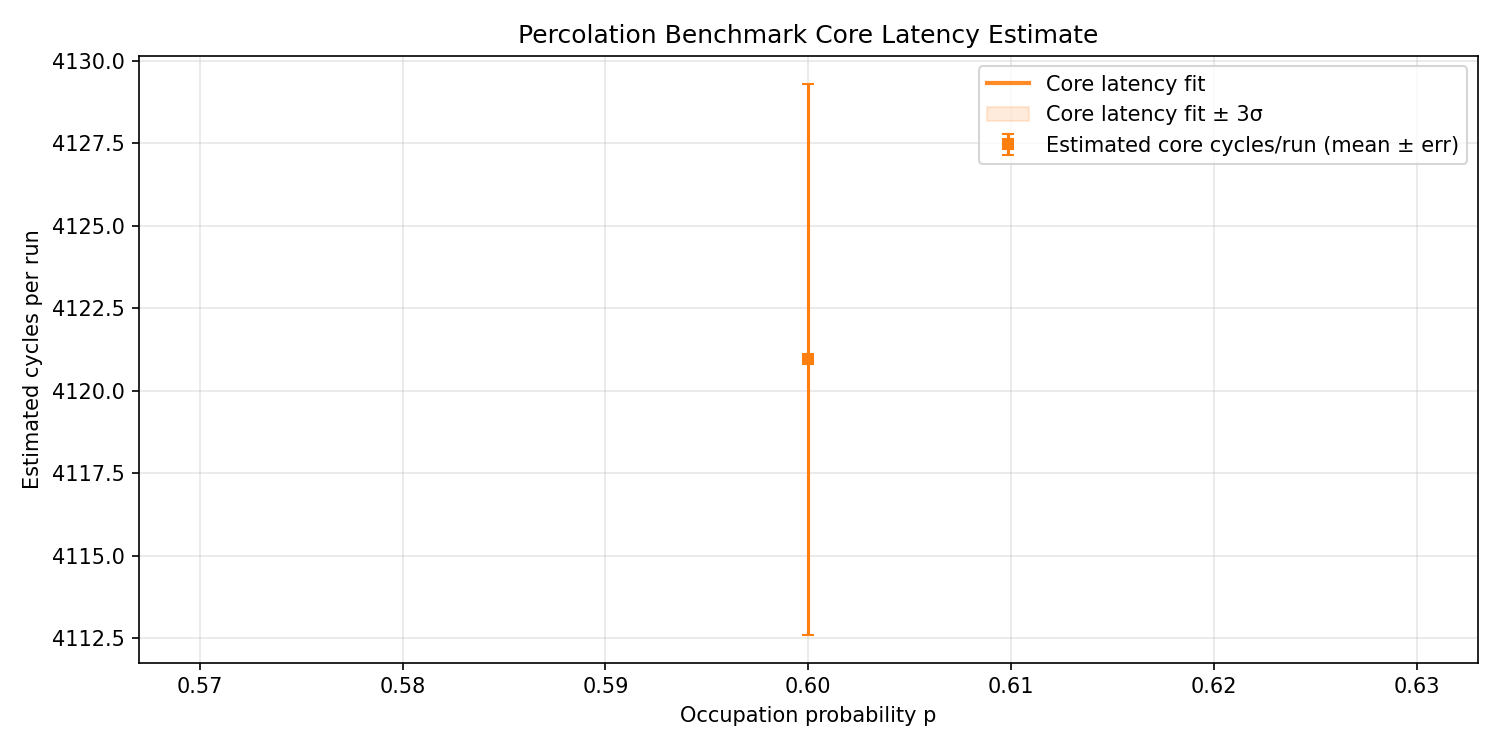

spanning_probability.png


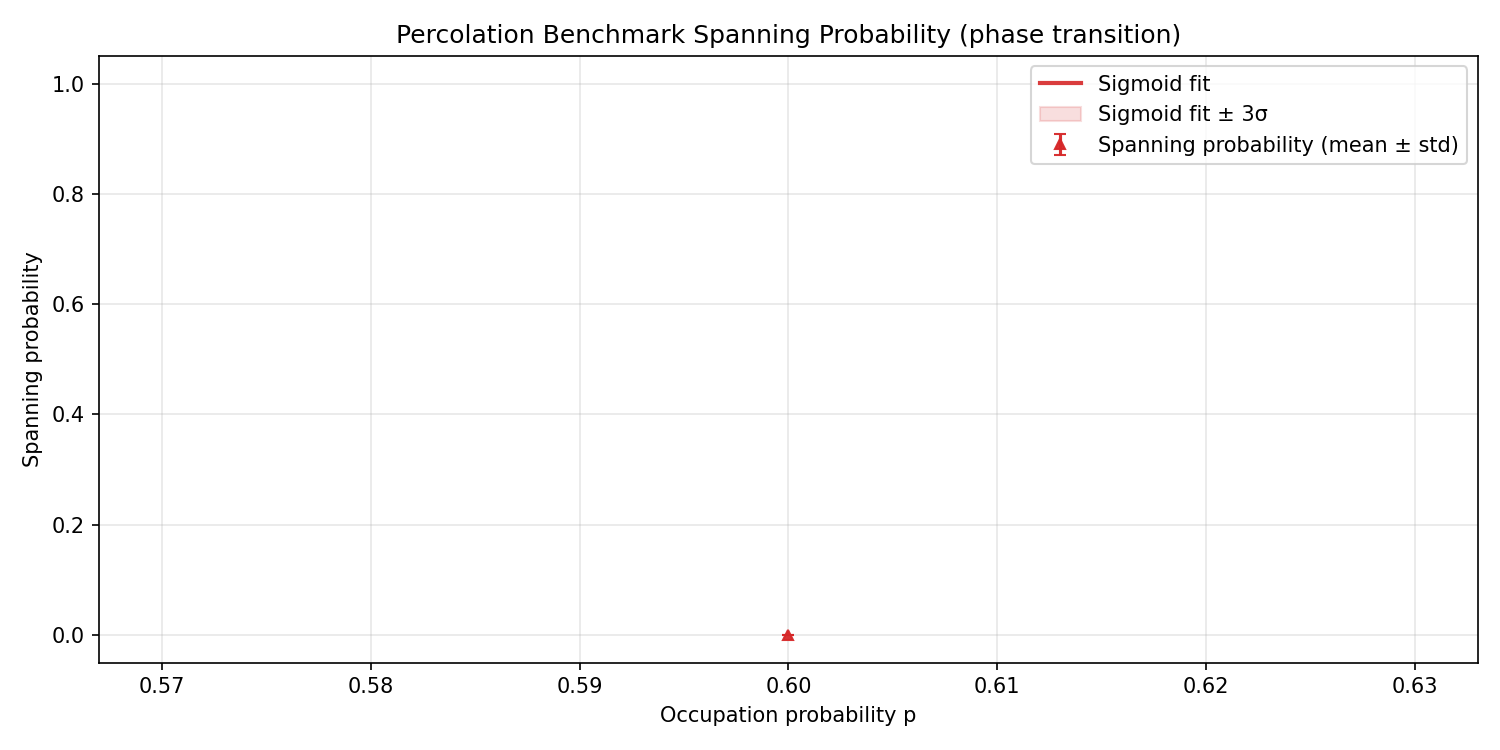

In [ ]:
def render_png(path: Path) -> None:
    if not path.exists():
        print(f'missing: {path}')
        return
    display(Image(filename=str(path)))

session_plot_dir = plot_dir / selected_session_id
session_plot_dir.mkdir(parents=True, exist_ok=True)

analysis.plot_dashboard(summary_rows, raw_rows, session_plot_dir / 'dashboard.png')
analysis.plot_front_density(raw_rows, session_plot_dir / 'front_density.png')
analysis.plot_cluster_mass(raw_rows, session_plot_dir / 'cluster_mass.png')
analysis.plot_occupancy_bias(raw_rows, session_plot_dir / 'occupancy_bias.png')
analysis.plot_core_latency(raw_rows, session_plot_dir / 'core_latency.png')
analysis.plot_spanning_probability(raw_rows, session_plot_dir / 'spanning_probability.png')

for filename in [
    'dashboard.png',
    'front_density.png',
    'cluster_mass.png',
    'occupancy_bias.png',
    'core_latency.png',
    'spanning_probability.png',
]:
    print(filename)
    render_png(session_plot_dir / filename)

## Optional batch view

Change `selected_session_index` and rerun the selection and rendering cells to inspect another benchmark session.

If you want to compare several sessions at once, keep the analysis logic in the module and use a small loop here to render one subdirectory per session.

## Sweep Session Explorer

This section inspects the recent latency sweep sessions collected with fixed probability `p = 0.60` and compares them by `steps_per_run` and `cfg_runs`.

It stays inside the notebook so the analysis logic remains in `percolation_uart.analysis` while the notebook only orchestrates filtering and plotting.

In [ ]:
SWEEP_RUNS = {1, 4, 16, 64, 256, 1024, 4096, 16384, 65600}
SWEEP_STEPS = {64, 128, 256, 512, 768, 1024, 2048}
SWEEP_WIDTHS = {64, 170}

def _session_signature(summary_rows, raw_rows):
    if not raw_rows:
        return None
    first_row = raw_rows[0]
    return {
        'runs': int(first_row['runs']),
        'steps': int(first_row['steps']),
        'width': int(first_row.get('hw_width', first_row.get('width', 0))),
        'points': len(summary_rows),
        'raw_rows': len(raw_rows),
        'summary_rows': len(summary_rows),
        'p_values': sorted({float(row['p']) for row in summary_rows}),
    }

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    sweep_sessions = []
    for session in sessions:
        summary_rows = analysis.load_summary_rows(conn, session_id=session.session_id)
        raw_rows = analysis.load_raw_rows(conn, session_id=session.session_id)
        signature = _session_signature(summary_rows, raw_rows)
        if signature is None:
            continue
        if signature['runs'] not in SWEEP_RUNS:
            continue
        if signature['steps'] not in SWEEP_STEPS:
            continue
        if SWEEP_WIDTHS is not None and signature['width'] not in SWEEP_WIDTHS:
            continue
        sweep_sessions.append((session, signature, summary_rows, raw_rows))
finally:
    conn.close()

print(f'found {len(sweep_sessions)} sweep sessions')
for index, (session, signature, summary_rows, raw_rows) in enumerate(sweep_sessions[-12:], start=max(1, len(sweep_sessions) - 11)):
    print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
    print(f'    runs={signature["runs"]} steps={signature["steps"]} width={signature["width"]} summary_rows={signature["summary_rows"]} raw_rows={signature["raw_rows"]}')
    print(f'    p_values={signature["p_values"]}')

found 219 sweep sessions
208. session_id=43483d55-a735-4b39-98c3-8f5fbff602b9 created_at=2026-05-15T16:10:44.122327+00:00
    runs=256 steps=1024 width=170 summary_rows=2 raw_rows=10
    p_values=[0.6]
209. session_id=1ce6fc47-e8b4-4423-9dd4-83f8db9a73bc created_at=2026-05-15T16:10:45.248237+00:00
    runs=1024 steps=1024 width=170 summary_rows=2 raw_rows=10
    p_values=[0.6]
210. session_id=301cfbef-401e-4b13-92a0-e4e24436f219 created_at=2026-05-15T16:10:47.644461+00:00
    runs=4096 steps=1024 width=170 summary_rows=2 raw_rows=10
    p_values=[0.6]
211. session_id=baa0fec8-794e-4b55-a86b-94016e74281c created_at=2026-05-15T16:10:55.018131+00:00
    runs=16384 steps=1024 width=170 summary_rows=2 raw_rows=10
    p_values=[0.6]
212. session_id=38652324-6771-4c29-8b38-53f26f3d753b created_at=2026-05-15T16:10:55.656959+00:00
    runs=1 steps=2048 width=170 summary_rows=2 raw_rows=10
    p_values=[0.6]
213. session_id=30fc8c7d-5b58-4716-ba31-84981da52ca5 created_at=2026-05-15T16:10:56.3140

session_id  width  steps   runs   latency_s  cycles/run  core_est  ideal_core  rows/s      cells/s
41eb1d3e     64     64       1   0.005707    570705.3  292927.5       195.0       11260        720660
d23efcd2     64     64       1   0.005751    575074.5  297296.7       195.0       11138        712822
337f32d2    170     64       1   0.005802    580211.3  302433.6       195.0       11044       1877443
5f6d34fa    170     64       1   0.005764    576355.6  298577.8       195.0       11111       1888863
9c7dfc4e     64     64       4   0.005708    142709.4   73264.9       195.0       44987       2879156
e54dd390     64     64       4   0.005720    143011.4   73567.0       195.0       44899       2873560
cef7fab7    170     64       4   0.005809    145213.4   75768.9       195.0       44128       7501702
9b56af04    170     64       4   0.005754    143862.2   74417.8       195.0       44522       7568672
447a9b63     64     64      16   0.005694     35587.8   18226.7       195.0      1803

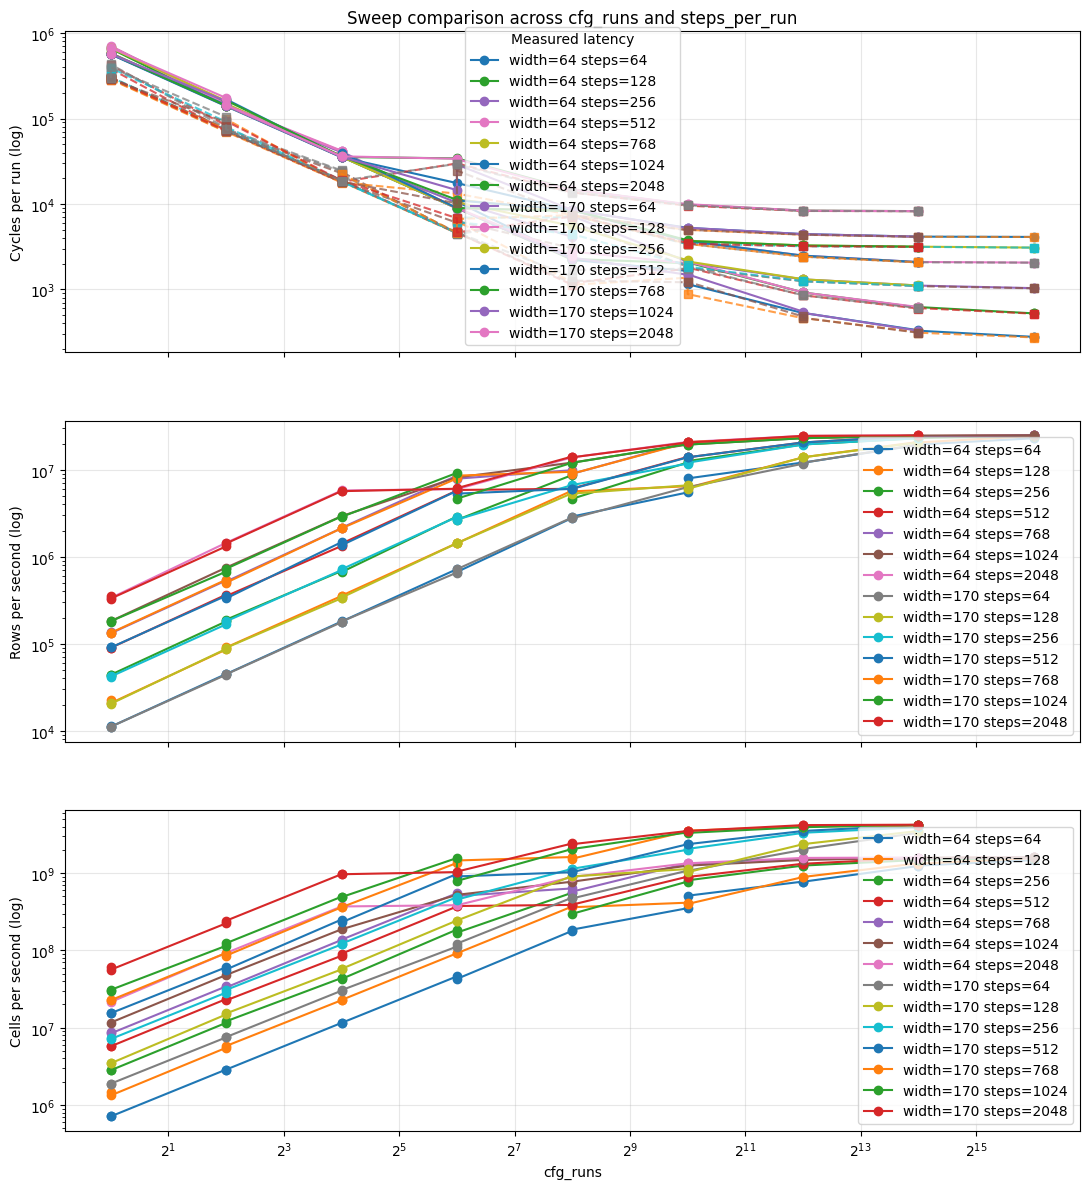

saved /home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/notebook_analysis/sweep_comparison/sweep_comparison.png


In [ ]:
def _mean(values):
    return sum(values) / len(values)

records = []
for session, signature, summary_rows, raw_rows in sweep_sessions:
    runs = float(signature['runs'])
    steps = float(signature['steps'])
    width = float(signature.get('width', raw_rows[0].get('hw_width', raw_rows[0].get('width', 0))))
    ideal_core_cycles = steps * 3.0 + 3.0
    latency_s = _mean([float(row['hw_latency_s']) for row in summary_rows])
    latency_cycles = _mean([float(row['hw_latency_per_run_cycles']) for row in summary_rows])
    core_cycles = _mean([float(row['hw_core_latency_per_run_cycles_est']) for row in summary_rows])
    runs_per_s = _mean([float(row['hw_runs_per_s']) for row in summary_rows])
    cells_per_s = _mean([float(row['hw_cells_per_s']) for row in summary_rows])
    rows_per_s = runs_per_s * steps
    records.append({
        'session_id': session.session_id,
        'created_at': session.created_at,
        'runs': runs,
        'steps': steps,
        'width': width,
        'latency_s': latency_s,
        'latency_cycles': latency_cycles,
        'core_cycles': core_cycles,
        'ideal_core_cycles': ideal_core_cycles,
        'runs_per_s': runs_per_s,
        'rows_per_s': rows_per_s,
        'cells_per_s': cells_per_s,
    })

records.sort(key=lambda record: (record['steps'], record['runs']))
if not records:
    raise RuntimeError('no sweep records found')

print('session_id  width  steps   runs   latency_s  cycles/run  core_est  ideal_core  rows/s      cells/s')
for record in records:
    print(
        f"{record['session_id'][:8]}  {int(record['width']):5d}  {int(record['steps']):5d}  {int(record['runs']):6d}  "
        f"{record['latency_s']:9.6f}  {record['latency_cycles']:10.1f}  {record['core_cycles']:8.1f}  "
        f"{record['ideal_core_cycles']:10.1f}  {record['rows_per_s']:10.0f}  {record['cells_per_s']:12.0f}"
    )

fig, axes = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
for width_value in sorted({record['width'] for record in records}):
    width_records = [record for record in records if record['width'] == width_value]
    for steps_value in sorted({record['steps'] for record in width_records}):
        subset = [record for record in width_records if record['steps'] == steps_value]
        xs = [record['runs'] for record in subset]
        label = f'width={int(width_value)} steps={int(steps_value)}'
        axes[0].plot(xs, [record['latency_cycles'] for record in subset], 'o-', label=label)
        axes[0].plot(xs, [record['core_cycles'] for record in subset], 's--', alpha=0.75)
        axes[1].plot(xs, [record['rows_per_s'] for record in subset], 'o-', label=label)
        axes[2].plot(xs, [record['cells_per_s'] for record in subset], 'o-', label=label)

axes[0].set_xscale('log', base=2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Cycles per run (log)')
axes[0].set_title('Sweep comparison across cfg_runs and steps_per_run')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Measured latency')

axes[1].set_yscale('log')
axes[1].set_ylabel('Rows per second (log)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].set_yscale('log')
axes[2].set_ylabel('Cells per second (log)')
axes[2].set_xlabel('cfg_runs')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
sweep_plot_dir = plot_dir / 'sweep_comparison'
sweep_plot_dir.mkdir(parents=True, exist_ok=True)
sweep_plot_path = sweep_plot_dir / 'sweep_comparison.png'
fig.savefig(sweep_plot_path, dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f'saved {sweep_plot_path}')